# Task 6 — Gateway Node Design: Phase 1 (Area Clustering)

Partition the 434 NE counties into freight **areas** within each of the 50 regions using **Simulated Annealing** (same architecture as Task 3 region clustering).

**Methodology:**
- Population-typed SA area clustering with two-component objective (compact + spread)
- Population is used for BFS initialization only; there is no SA balance term or population-floor constraint
- Hard constraints: adjacency, non-empty donor, contiguity
- Region types (A/B/C) determine minimum area targets (4/3/2)
- Large-span regions (>150 mi) exempt from 80-mile spread penalty

**Subtask pipeline:**
- **6.1** Population Data Acquisition (Census 2020 DEC PL + ACS 5-yr fallback)
- **6.2** Region Type Classification (A/B/C by composite population score)
- **6.3** SA Objective Setup & Initialization (per-region parameters)
- **6.4** SA Area Clustering (run area_clustering.py per region)
- **6.5** Area Post-Processing (contiguity + travel-time audits)
- **6.6** Area Outputs (CSV + map)

**Module:** `Task6/area_clustering.py` (standalone SA implementation patterned after Task 3)

**Output target:** nominal uncapped target = 150 areas; effective target after `min_areas_effective = min(type target, n_counties)` is computed in 6.2.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import requests
import time
import warnings
import networkx as nx

warnings.filterwarnings('ignore')

# Add Task6 to path for module import
ROOT = Path('/home/hty/Documents/Working Projects/ISYE6339_Case2')
sys.path.insert(0, str(ROOT / 'Task6'))

# ── Paths ──────────────────────────────────────────────────────────────────
DATA6      = ROOT / 'Data' / 'Task6'
DATA3      = ROOT / 'Data' / 'Task3'
DATA3_OUT  = DATA3 / 'outputs'
DATA3_DRV  = DATA3 / 'derived'
DATA3_CACHE = DATA3 / 'cache'

(DATA6 / 'figures').mkdir(parents=True, exist_ok=True)
(DATA6 / 'cache').mkdir(parents=True, exist_ok=True)

print('Paths OK')
print(f'ROOT: {ROOT}')

Paths OK
ROOT: /home/hty/Documents/Working Projects/ISYE6339_Case2


---
## 6.1 — Population Data Acquisition

Fetch Census 2020 DEC PL county-level total population (`P1_001N`) for the 434 NE counties. For any county missing from the DEC PL response, fall back to ACS 5-year estimate (`B01003_001E`, vintage 2022).

**State FIPS in scope:** 09 CT · 10 DE · 11 DC · 23 ME · 24 MD · 25 MA · 33 NH · 34 NJ · 36 NY · 42 PA · 44 RI · 50 VT · 51 VA · 54 WV

**Formula:**

$$\text{pop2020}_c = \begin{cases}
\text{DEC PL}\ P1\_001N & \text{if available} \\
\text{ACS 5-yr}\ B01003\_001E & \text{if DEC missing} \\
\text{median}(\text{pop2020}) & \text{if both missing}
\end{cases}$$

In [2]:
# ── Load reference FIPS set ────────────────────────────────────────────────
region_assign = pd.read_csv(DATA3_OUT / 'region_assignment.csv')
region_assign['fips'] = region_assign['fips'].astype(str).str.zfill(5)
ne_fips = set(region_assign['fips'])
print(f'NE counties in scope: {len(ne_fips)}')

NE counties in scope: 434


In [3]:
POP_PATH = DATA6 / 'ne_county_population.csv'

if POP_PATH.exists():
    pop_df = pd.read_csv(POP_PATH, dtype={'fips': str})
    pop_df['fips'] = pop_df['fips'].str.zfill(5)
    print(f'✓ Loaded from cache: {len(pop_df)} rows')
else:
    NE_STATE_FIPS = ['09','10','11','23','24','25','33','34','36','42','44','50','51','54']
    
    # ── DEC PL pull ─────────────────────────────────────────────────────────
    dec_rows = []
    DEC_URL = 'https://api.census.gov/data/2020/dec/pl'
    
    for sf in NE_STATE_FIPS:
        r = requests.get(
            DEC_URL, 
            params={'get': 'P1_001N', 'for': 'county:*', 'in': f'state:{sf}'},
            timeout=30
        )
        if r.status_code != 200:
            print(f'  DEC PL: state {sf} status {r.status_code}')
            continue
        
        data = r.json()
        hdr = data[0]
        for row in data[1:]:
            fips = row[hdr.index('state')] + row[hdr.index('county')]
            pop  = int(row[hdr.index('P1_001N')])
            dec_rows.append({'fips': fips, 'pop2020': pop})
        time.sleep(0.1)
    
    dec_df = pd.DataFrame(dec_rows)
    dec_df['fips'] = dec_df['fips'].str.zfill(5)
    print(f'DEC PL returned {len(dec_df)} county rows')
    
    pop_map = dict(zip(dec_df['fips'], dec_df['pop2020']))
    missing_fips = ne_fips - set(pop_map.keys())
    print(f'Missing after DEC PL: {len(missing_fips)} → {sorted(missing_fips)}')
    
    # ── ACS 5-year fallback ─────────────────────────────────────────────────
    if missing_fips:
        ACS_URL = 'https://api.census.gov/data/2022/acs/acs5'
        missing_states = {f[:2] for f in missing_fips}
        
        for sf in missing_states:
            r = requests.get(
                ACS_URL, 
                params={'get': 'B01003_001E', 'for': 'county:*', 'in': f'state:{sf}'},
                timeout=30
            )
            if r.status_code != 200:
                continue
            
            data = r.json()
            hdr = data[0]
            for row in data[1:]:
                fips = row[hdr.index('state')] + row[hdr.index('county')]
                if fips in missing_fips:
                    pop_map[fips] = int(row[hdr.index('B01003_001E')])
            time.sleep(0.1)
    
    # ── Build final dataframe ───────────────────────────────────────────────
    records = [{'fips': f, 'pop2020': pop_map.get(f, np.nan)} for f in sorted(ne_fips)]
    pop_df = pd.DataFrame(records)
    
    still_missing = pop_df[pop_df['pop2020'].isna()]
    if len(still_missing):
        med_pop = pop_df['pop2020'].median()
        pop_df['pop2020'] = pop_df['pop2020'].fillna(med_pop)
        print(f'Imputed {len(still_missing)} missing with median {med_pop:,.0f}')
    
    pop_df['pop2020'] = pop_df['pop2020'].astype(int)
    pop_df.to_csv(POP_PATH, index=False)
    print(f'✓ Saved {len(pop_df)} rows → {POP_PATH.name}')

# ── Sanity ─────────────────────────────────────────────────────────────────
assert len(pop_df) == len(ne_fips), f'Row count mismatch: {len(pop_df)} vs {len(ne_fips)}'
assert pop_df['pop2020'].isna().sum() == 0, 'NaN populations remain'
assert (pop_df['pop2020'] > 0).all(), 'Non-positive population found'

print(f'\n✓ 6.1 complete — {len(pop_df)} counties')
print(f'  Population range: [{pop_df.pop2020.min():,} – {pop_df.pop2020.max():,}]')
print(f'  Median: {pop_df.pop2020.median():,.0f}')

✓ Loaded from cache: 434 rows

✓ 6.1 complete — 434 counties
  Population range: [2,232 – 2,736,074]
  Median: 52,938


---
## 6.2 — Region Type Classification

Classify the 50 regions as **Type A (Urban)**, **Type B (Suburban)**, or **Type C (Rural)** using a composite population score.

**Composite Score:**

$$\text{score}_r = 0.6 \cdot \text{rank}(\text{total\_pop}_r) + 0.4 \cdot \text{rank}(\text{max\_county\_pop}_r)$$

**Type Assignment (by tertile):**
- **Type A (Urban/Metro)**: top tertile (17 regions) → target ≥ 4 areas per region
- **Type B (Suburban)**: middle tertile (16 regions) → target ≥ 3 areas per region
- **Type C (Rural/Sparse)**: bottom tertile (17 regions) → target ≥ 2 areas per region

**Minimum Effective Areas (floor cap):**

$$\text{min\_areas\_effective}[r] = \min\!\left(\text{min\_areas\_type}[\text{type}(r)],\ n_{\text{counties}}[r]\right)$$

Rationale: a region cannot produce more areas than it has counties.

In [4]:
# ── Compute region-level population summary ────────────────────────────────
merged = region_assign.merge(pop_df, on='fips', how='left')

reg_pop = merged.groupby('region_id').agg(
    total_pop      = ('pop2020', 'sum'),
    max_county_pop = ('pop2020', 'max'),
    n_counties     = ('fips', 'count')
).reset_index()

# ── Composite score ─────────────────────────────────────────────────────────
reg_pop['rank_total'] = reg_pop['total_pop'].rank()
reg_pop['rank_max']   = reg_pop['max_county_pop'].rank()
reg_pop['score']      = 0.6 * reg_pop['rank_total'] + 0.4 * reg_pop['rank_max']

# ── Tertile cut-points ──────────────────────────────────────────────────────
q33 = reg_pop['score'].quantile(1/3)
q67 = reg_pop['score'].quantile(2/3)

def assign_type(score):
    if score > q67: return 'A'
    if score > q33: return 'B'
    return 'C'

reg_pop['region_type'] = reg_pop['score'].apply(assign_type)

# ── Min areas per type ──────────────────────────────────────────────────────
MIN_AREAS_TYPE = {'A': 4, 'B': 3, 'C': 2}
reg_pop['min_areas_type']      = reg_pop['region_type'].map(MIN_AREAS_TYPE)
reg_pop['min_areas_effective'] = reg_pop[['min_areas_type', 'n_counties']].min(axis=1)

# ── Summary ─────────────────────────────────────────────────────────────────
type_counts = reg_pop['region_type'].value_counts().sort_index()
print('Region Type Distribution:')
for t in ['A','B','C']:
    sub = reg_pop[reg_pop.region_type == t]
    cnt = type_counts.get(t, 0)
    print(f'  Type {t}: {cnt:2d} regions | total_pop [{sub.total_pop.min():>7,} – {sub.total_pop.max():>7,}]'
          f' | median {sub.total_pop.median():>7,.0f}')

capped = reg_pop[reg_pop.min_areas_effective < reg_pop.min_areas_type]
print(f'\nMin-areas capped (< type target): {len(capped)} regions')
if len(capped) > 0:
    print(capped[['region_id','region_type','n_counties','min_areas_type','min_areas_effective']].to_string(index=False))

# ── Validation ──────────────────────────────────────────────────────────────
assert len(reg_pop) == 50, f'Expected 50 regions, got {len(reg_pop)}'
assert set(reg_pop['region_type']) == {'A','B','C'}, 'Invalid region types'
assert (reg_pop['min_areas_effective'] >= 1).all(), 'Invalid min_areas_effective'

print('\n✓ 6.2 complete — 50 regions classified')

Region Type Distribution:
  Type A: 17 regions | total_pop [1,250,578 – 8,558,979] | median 2,428,386
  Type B: 16 regions | total_pop [716,222 – 1,757,841] | median 954,964
  Type C: 17 regions | total_pop [429,228 – 872,583] | median 696,241

Min-areas capped (< type target): 9 regions
 region_id region_type  n_counties  min_areas_type  min_areas_effective
         0           A           1               4                    1
         3           A           2               4                    2
         7           B           1               3                    1
        12           B           1               3                    1
        17           A           2               4                    2
        18           B           2               3                    2
        34           A           2               4                    2
        36           A           2               4                    2
        42           A           2               4             

---
## 6.3 — SA Objective Setup

Define the SA objective and per-region parameters.

### Objective (two-component)

$$J_r = w_\text{compact} \cdot C_\text{compact} + w_\text{spread} \cdot C_\text{spread}$$

$$C_\text{compact} = \frac{1}{N_r \cdot D_r^2} \sum_{i \in r} \|(x_i, y_i) - \mu_{a_i}\|^2$$

$$C_\text{spread} = \frac{1}{k_r} \sum_{a \notin \text{exempt}} \left(\frac{\max(0,\ d_{\max,a} - 80\ \text{mi})}{80\ \text{mi}}\right)^2$$

**Why no balance term:** Areas are geographic groupings for gateway hub siting only.
Phase 2 scales hub count to each area's own freight demand independently — cross-area
population equity is not a design requirement at this tier.  The population-balance
term ($C_\text{balance}$, $w=3.0$) and the hard population-floor constraint
($p_\text{min} = p^*$) from the original formulation have been removed.
Population (`pop2020`) is now used only in the BFS initializer to produce
roughly equal starting areas; the SA optimises purely on compactness and spread.

**Weights:** $w_\text{compact} = 1.0$, $w_\text{spread} = 2.0$

**Spread-exempt regions** (span > 150 mi): 4, 9, 15, 19, 21, 32, 33, 41, 46

In [5]:
# ── Per-region p_target (BFS initializer only — not a hard SA constraint) ──
# p_target guides the BFS growing to produce roughly balanced starting areas.
# The SA itself has no population floor; areas can be any size after optimisation.
reg_pop['pop_target'] = reg_pop['total_pop'] / reg_pop['min_areas_effective']

print('Per-region pop_target (BFS init reference) by type:')
for t in ['A','B','C']:
    sub = reg_pop[reg_pop.region_type == t]
    print(f'  Type {t}: min {sub.pop_target.min():>10,.0f} | median {sub.pop_target.median():>10,.0f} | max {sub.pop_target.max():>10,.0f}')

print('\nObjective weights: w_compact=1.0, w_spread=2.0 (no balance term)')
print('Hard constraints: adjacency + non-empty + contiguity only (no population floor)')
print('\n✓ 6.3 complete')

Per-region pop_target (BFS init reference) by type:
  Type A: min    368,973 | median    844,817 | max  2,139,745
  Type B: min    238,741 | median    334,191 | max    954,236
  Type C: min    214,614 | median    348,120 | max    436,292

Objective weights: w_compact=1.0, w_spread=2.0 (no balance term)
Hard constraints: adjacency + non-empty + contiguity only (no population floor)

✓ 6.3 complete


---
## 6.4 — SA Area Clustering

Run the Simulated Annealing area clustering for all 50 regions using `area_clustering.py`.

**Objective:** $J_r = C_\text{compact} + 2 \cdot C_\text{spread}$ (no balance term)

**Hard Constraints:**
1. **Adjacency**: county must border target area
2. **Non-empty donor**: donor area cannot be emptied
3. **Contiguity**: donor area must remain connected

**SA Parameters:**
- `n_proposals`: max(5,000, 800 × n_counties)
- `alpha`: 0.998 (cooling rate)
- `T0`: sampled from 200 random feasible |ΔJ|
- `patience`: 2,000 (early stop)
- `n_restarts`: 2

In [6]:
# Import the area clustering module
import area_clustering

# ── Load spatial data ───────────────────────────────────────────────────────
gdf_all = gpd.read_file(DATA3_DRV / 'ne_counties_prepared.gpkg')
gdf_all['fips'] = gdf_all['fips'].astype(str).str.zfill(5)

edges_df = pd.read_parquet(DATA3_CACHE / 'ne_county_edges.parquet')
edges_df['fips_a'] = edges_df['fips_a'].astype(str).str.zfill(5)
edges_df['fips_b'] = edges_df['fips_b'].astype(str).str.zfill(5)

# Attach pop2020, region_id, and Task 3 external throughput
gdf_all = gdf_all.merge(pop_df[['fips','pop2020']], on='fips', how='left')
gdf_all = gdf_all.merge(
    region_assign[['fips','region_id','external_throughput_ktons']],
    on='fips', how='left'
)

assert gdf_all['pop2020'].isna().sum() == 0, 'Missing pop2020 after merge'
assert gdf_all['region_id'].isna().sum() == 0, 'Missing region_id after merge'
assert gdf_all['external_throughput_ktons'].isna().sum() == 0, 'Missing external throughput after merge'

print(f'gdf_all: {len(gdf_all)} counties')
print(f'edges_df: {len(edges_df)} edges')

gdf_all: 434 counties
edges_df: 1096 edges


In [7]:
# ── Define spread-exempt regions ────────────────────────────────────────────
# EDA-confirmed large-span regions (>150 mi) from Doc/Task.md
EXEMPT_REGION_IDS = {4, 9, 15, 19, 21, 32, 33, 41, 46}

print(f'Spread-exempt regions (>150 mi span): {sorted(EXEMPT_REGION_IDS)}')

Spread-exempt regions (>150 mi span): [4, 9, 15, 19, 21, 32, 33, 41, 46]


In [8]:
# Import the area clustering module (reload to pick up edits)
import importlib
import area_clustering
importlib.reload(area_clustering)

# ── Load spatial data ───────────────────────────────────────────────────────
gdf_all = gpd.read_file(DATA3_DRV / 'ne_counties_prepared.gpkg')
gdf_all['fips'] = gdf_all['fips'].astype(str).str.zfill(5)

edges_df = pd.read_parquet(DATA3_CACHE / 'ne_county_edges.parquet')
edges_df['fips_a'] = edges_df['fips_a'].astype(str).str.zfill(5)
edges_df['fips_b'] = edges_df['fips_b'].astype(str).str.zfill(5)

# Attach pop2020, region_id, and Task 3 external throughput
gdf_all = gdf_all.merge(pop_df[['fips','pop2020']], on='fips', how='left')
gdf_all = gdf_all.merge(
    region_assign[['fips','region_id','external_throughput_ktons']],
    on='fips', how='left'
)

assert gdf_all['pop2020'].isna().sum() == 0, 'Missing pop2020 after merge'
assert gdf_all['region_id'].isna().sum() == 0, 'Missing region_id after merge'
assert gdf_all['external_throughput_ktons'].isna().sum() == 0, 'Missing external throughput after merge'

print(f'gdf_all: {len(gdf_all)} counties')
print(f'edges_df: {len(edges_df)} edges')

# ── Run SA clustering for all regions ───────────────────────────────────────
AREA_CACHE_PATH = DATA6 / 'cache' / 'area_labels.parquet'

expected_areas = reg_pop.set_index('region_id')['min_areas_effective'].astype(int)

def cache_is_valid(df):
    required = {'fips', 'region_id', 'area_id'}
    if not required.issubset(df.columns):
        return False, 'missing required columns'
    df = df.copy()
    df['fips'] = df['fips'].astype(str).str.zfill(5)
    if len(df) != len(ne_fips) or set(df['fips']) != ne_fips:
        return False, 'county coverage mismatch'
    got = df.groupby('region_id')['area_id'].nunique().reindex(expected_areas.index)
    bad = got[got.astype(int) != expected_areas]
    if len(bad):
        return False, f'area count mismatch in regions {bad.index.tolist()[:10]}'
    return True, 'valid'

use_cache = False
if AREA_CACHE_PATH.exists():
    cached_area_label_df = pd.read_parquet(AREA_CACHE_PATH)
    use_cache, cache_msg = cache_is_valid(cached_area_label_df)
    if use_cache:
        area_label_df = cached_area_label_df.copy()
        area_label_df['fips'] = area_label_df['fips'].astype(str).str.zfill(5)
        print(f'✓ Loaded valid cache: {len(area_label_df)} counties, {area_label_df.area_id.nunique()} areas')
    else:
        print(f'Cache invalid ({cache_msg}); recomputing area labels...')

if not use_cache:
    print('Running SA area clustering for all 50 regions...\n')
    print('Objective: compact + spread only (no balance term)')
    print('Feasibility: adjacency + non-empty + contiguity (no population floor)\n')

    # region_info no longer needs p_min column
    region_info_sa = reg_pop[['region_id','region_type','n_counties','total_pop','min_areas_effective']].copy()

    area_label_df = area_clustering.run_all_regions(
        gdf=gdf_all,
        edges_df=edges_df,
        region_info=region_info_sa,
        exempt_region_ids=EXEMPT_REGION_IDS,
        cache_dir=DATA6 / 'cache',
        verbose=True
    )

    area_label_df.to_parquet(AREA_CACHE_PATH, index=False)
    print(f'\n✓ Saved → {AREA_CACHE_PATH.name}')

# ── Summary ─────────────────────────────────────────────────────────────────
n_areas = area_label_df['area_id'].nunique()
print(f'\n✓ 6.4 complete — {len(area_label_df)} counties → {n_areas} areas')
expected_total_areas = int(expected_areas.sum())
nominal_uncapped_areas = int(reg_pop['min_areas_type'].sum())
print(f'  Effective planned areas after county-count cap: {expected_total_areas}')
print(f'  Nominal uncapped type-target total: {nominal_uncapped_areas}')

areas_per_region = area_label_df.groupby('region_id')['area_id'].nunique()
assert areas_per_region.reindex(expected_areas.index).astype(int).equals(expected_areas), \
    'Area counts do not match min_areas_effective'
print(f'  Areas per region: [{areas_per_region.min()} – {areas_per_region.max()}] | median {areas_per_region.median():.0f}')

gdf_all: 434 counties
edges_df: 1096 edges
✓ Loaded valid cache: 434 counties, 132 areas

✓ 6.4 complete — 434 counties → 132 areas
  Effective planned areas after county-count cap: 132
  Nominal uncapped type-target total: 150
  Areas per region: [1 – 4] | median 2


---
## 6.5 — Area Post-Processing

Validate SA outputs and compute diagnostic metrics.

### Checks:
1. **Contiguity verification** (assertion) — BFS-verify each area is connected
2. **Travel-time audit** (informational) — log areas exceeding 80-mile cross-area distance (non-exempt only)
3. **Infrastructure check** (soft) — log areas with no interstate county

All checks are informational; SA hard constraints guarantee contiguity, so failures here indicate edge cases or island assignments.

In [9]:
# ── Load area assignments ───────────────────────────────────────────────────
area_df = area_label_df.copy()
area_df = area_df.merge(gdf_all[['fips','centroid_x','centroid_y']], on='fips', how='left')

print(f'Area assignment table: {len(area_df)} counties')

Area assignment table: 434 counties


In [10]:
# ── 1. Contiguity Verification ──────────────────────────────────────────────
print('Checking contiguity...')

contiguity_fails = []

for area_id in area_df['area_id'].unique():
    area_fips = area_df[area_df.area_id == area_id]['fips'].tolist()
    
    if len(area_fips) == 1:
        continue  # Single-county area is trivially contiguous
    
    # Build subgraph
    area_fips_set = set(area_fips)
    sub_edges = edges_df[
        edges_df['fips_a'].isin(area_fips_set) & 
        edges_df['fips_b'].isin(area_fips_set)
    ]
    
    G = nx.Graph()
    for _, row in sub_edges.iterrows():
        G.add_edge(row['fips_a'], row['fips_b'])
    
    # Ensure all counties are nodes
    for f in area_fips:
        if f not in G:
            G.add_node(f)
    
    # Check connectivity
    if not nx.is_connected(G):
        contiguity_fails.append(area_id)

if contiguity_fails:
    print(f'  ⚠ Contiguity failures: {len(contiguity_fails)} areas')
    print(f'  {contiguity_fails[:10]}')  # Show first 10
else:
    print('  ✓ All areas are contiguous')

Checking contiguity...
  ✓ All areas are contiguous


In [11]:
# ── 2. Travel-Time Audit ────────────────────────────────────────────────────
print('\nAuditing cross-area distances...')

from scipy.spatial.distance import pdist

distance_violations = []

for area_id in area_df['area_id'].unique():
    region_id = int(area_id.split('_')[0])
    
    # Skip if region is exempt
    if region_id in EXEMPT_REGION_IDS:
        continue
    
    area_coords = area_df[area_df.area_id == area_id][['centroid_x','centroid_y']].to_numpy()
    
    if len(area_coords) < 2:
        continue
    
    # Max pairwise distance (meters → miles)
    dists = pdist(area_coords, metric='euclidean')
    max_dist_m = dists.max()
    max_dist_mi = max_dist_m / 1609.34
    
    if max_dist_mi > 80:
        distance_violations.append({
            'area_id': area_id,
            'region_id': region_id,
            'max_dist_mi': max_dist_mi
        })

if distance_violations:
    viol_df = pd.DataFrame(distance_violations)
    print(f'  ⚠ Distance violations (>80 mi): {len(viol_df)} areas')
    print(viol_df.head(10).to_string(index=False))
else:
    print('  ✓ All non-exempt areas satisfy 80-mile guideline')


Auditing cross-area distances...


  ✓ All non-exempt areas satisfy 80-mile guideline


In [12]:
# ── 3. Infrastructure Check ─────────────────────────────────────────────────
print('\nChecking interstate access...')

# Load infrastructure edges
edges_infra = pd.read_parquet(DATA3_CACHE / 'ne_county_edges_infra.parquet')
edges_infra['fips_a'] = edges_infra['fips_a'].astype(str).str.zfill(5)
edges_infra['fips_b'] = edges_infra['fips_b'].astype(str).str.zfill(5)

# Counties with interstate
interstate_edges = edges_infra[edges_infra['interstate_km'] > 0]
counties_with_interstate = set(interstate_edges['fips_a']).union(set(interstate_edges['fips_b']))

areas_no_interstate = []

for area_id in area_df['area_id'].unique():
    area_fips = set(area_df[area_df.area_id == area_id]['fips'])
    
    if not area_fips.intersection(counties_with_interstate):
        areas_no_interstate.append(area_id)

if areas_no_interstate:
    print(f'  ⚠ Areas with no interstate county: {len(areas_no_interstate)}')
    print(f'  {areas_no_interstate[:10]}')
else:
    print('  ✓ All areas have at least one interstate county')

print('\n✓ 6.5 complete — post-processing checks done')


Checking interstate access...
  ⚠ Areas with no interstate county: 11
  ['2_1', '2_3', '11_2', '13_1', '13_3', '22_0', '25_0', '25_1', '31_0', '35_2']

✓ 6.5 complete — post-processing checks done


---
## 6.6 — Area Outputs

Produce final area assignment table, metrics, and visualization.

### Output Files:
1. `area_assignment.csv` — 434 rows × 7 cols (fips, county_name, state, region_id, region_type, area_id, pop2020)
2. `area_metrics.csv` — one row per area × 10 cols (area_id, region_id, region_type, n_counties, total_pop, centroid_x_m, centroid_y_m, external_throughput_ktons, max_cross_area_dist_miles, has_interstate)
3. `fig_area_map.png` — NE map with counties colored by area, region outlines, region_type labels

### Area Centroid (population-weighted):

$$\mu_a = \frac{\sum_{c \in a} p_c \cdot (x_c, y_c)}{\sum_{c \in a} p_c}$$

In [13]:
# ── Build area_assignment.csv ───────────────────────────────────────────────
county_names = region_assign[['fips','county_name','state']].copy()

area_assignment = area_df[['fips','region_id','area_id']].merge(
    county_names, on='fips', how='left'
).merge(
    pop_df[['fips','pop2020']], on='fips', how='left'
).merge(
    reg_pop[['region_id','region_type']], on='region_id', how='left'
)

area_assignment = area_assignment[['fips','county_name','state','region_id','region_type','area_id','pop2020']]
area_assignment = area_assignment.sort_values(['region_id','area_id','fips']).reset_index(drop=True)

AREA_ASSIGNMENT_PATH = DATA6 / 'area_assignment.csv'
area_assignment.to_csv(AREA_ASSIGNMENT_PATH, index=False)
print(f'✓ Saved area_assignment.csv ({len(area_assignment)} rows)')

✓ Saved area_assignment.csv (434 rows)


In [14]:
# ── Build area_metrics.csv ──────────────────────────────────────────────────
area_full = area_assignment.merge(
    gdf_all[['fips','centroid_x','centroid_y','external_throughput_ktons']], 
    on='fips', how='left'
)

area_metrics = []

for area_id in area_full['area_id'].unique():
    sub = area_full[area_full.area_id == area_id]
    
    region_id = sub['region_id'].iloc[0]
    region_type = sub['region_type'].iloc[0]
    n_counties = len(sub)
    total_pop = sub['pop2020'].sum()
    
    # Population-weighted centroid
    total_weight = total_pop
    if total_weight > 0:
        centroid_x = (sub['centroid_x'] * sub['pop2020']).sum() / total_weight
        centroid_y = (sub['centroid_y'] * sub['pop2020']).sum() / total_weight
    else:
        centroid_x = sub['centroid_x'].mean()
        centroid_y = sub['centroid_y'].mean()
    
    # External throughput
    ext_throughput = sub['external_throughput_ktons'].sum()
    
    # Max cross-area distance
    coords = sub[['centroid_x','centroid_y']].to_numpy()
    if len(coords) >= 2:
        dists = pdist(coords, metric='euclidean')
        max_dist_mi = dists.max() / 1609.34
    else:
        max_dist_mi = 0.0
    
    # Interstate access
    has_interstate = bool(set(sub['fips']).intersection(counties_with_interstate))
    
    area_metrics.append({
        'area_id': area_id,
        'region_id': region_id,
        'region_type': region_type,
        'n_counties': n_counties,
        'total_pop': int(total_pop),
        'centroid_x_m': centroid_x,
        'centroid_y_m': centroid_y,
        'external_throughput_ktons': ext_throughput,
        'max_cross_area_dist_miles': max_dist_mi,
        'has_interstate': has_interstate
    })

area_metrics_df = pd.DataFrame(area_metrics)
area_metrics_df = area_metrics_df.sort_values(['region_id','area_id']).reset_index(drop=True)

AREA_METRICS_PATH = DATA6 / 'area_metrics.csv'
area_metrics_df.to_csv(AREA_METRICS_PATH, index=False)
print(f'✓ Saved area_metrics.csv ({len(area_metrics_df)} rows)')

✓ Saved area_metrics.csv (132 rows)


In [15]:
# ── Prepare map data ────────────────────────────────────────────────────────
gdf_map = gdf_all[['fips','geometry']].merge(
    area_assignment[['fips','region_id','area_id','region_type']], 
    on='fips', how='left'
)

# Build region boundaries (dissolve by region_id)
gdf_regions = gdf_map.dissolve(by='region_id', as_index=False)[['region_id','geometry']]

print(f'Map data: {len(gdf_map)} counties, {len(gdf_regions)} regions')

Map data: 434 counties, 50 regions


✓ Saved fig_area_map.png


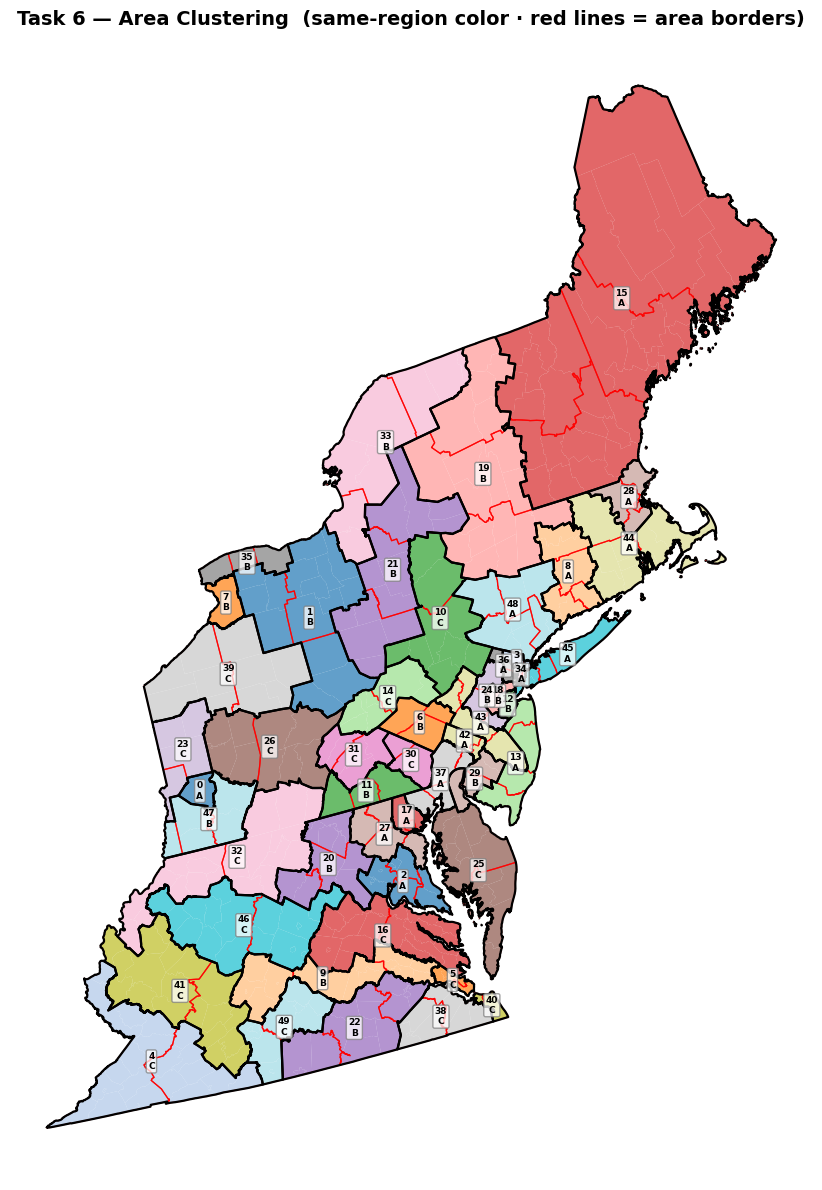

In [16]:
# ── Assign one color per region (same color across all areas in a region) ────
import matplotlib.cm as cm

n_regions = len(gdf_regions)
cmap = cm.get_cmap('tab20', n_regions)
region_color = {int(row['region_id']): cmap(i) for i, row in gdf_regions.reset_index(drop=True).iterrows()}

gdf_map['color'] = gdf_map['region_id'].map(region_color)

# ── Build area geometries for border drawing ──────────────────────────────
gdf_areas = gdf_map.dissolve(by='area_id', as_index=False)[['area_id','geometry']]

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')

# County polygons colored by region (all areas in same region share color)
for rid, color in region_color.items():
    sub = gdf_map[gdf_map.region_id == rid]
    sub.plot(ax=ax, color=color, edgecolor='none', alpha=0.7)

# Area boundaries — bold red lines show subdivisions within each region
gdf_areas.boundary.plot(ax=ax, color='red', linewidth=0.9, alpha=0.85)

# Region outer boundaries — thick black
gdf_regions.boundary.plot(ax=ax, color='black', linewidth=1.6, alpha=1.0)

# Region type labels
for _, row in reg_pop.iterrows():
    rid = row['region_id']
    rtype = row['region_type']
    geom = gdf_regions[gdf_regions.region_id == rid]['geometry'].iloc[0]
    ax.text(
        geom.centroid.x, geom.centroid.y,
        f"{rid}\n{rtype}",
        ha='center', va='center',
        fontsize=6.5, fontweight='bold', color='black',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='gray', alpha=0.75)
    )

ax.set_title('Task 6 — Area Clustering  (same-region color · red lines = area borders)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()

FIG_PATH = DATA6 / 'figures' / 'fig_area_map.png'
plt.savefig(FIG_PATH, dpi=200, bbox_inches='tight', facecolor='white')
print(f'✓ Saved {FIG_PATH.name}')
plt.show()

---
## Summary

**Task 6 Phase 1 Complete**

✓ **6.1** — Population data acquired (434 counties, Census 2020 DEC PL + ACS fallback)  
✓ **6.2** — Region types classified (A/B/C by population tertiles)  
✓ **6.3** — SA objective configured (compact + spread; population only guides initialization)  
✓ **6.4** — SA area clustering executed (area_clustering.py, 50 regions)  
✓ **6.5** — Post-processing checks complete (contiguity, distance, infrastructure)  
✓ **6.6** — Outputs generated (area_assignment.csv, area_metrics.csv, fig_area_map.png)

**Final Outputs:**
- `Data/Task6/area_assignment.csv` — 434 counties → areas
- `Data/Task6/area_metrics.csv` — per-area summary metrics
- `Data/Task6/figures/fig_area_map.png` — area map with region types
- `Data/Task6/cache/area_labels.parquet` — intermediate cache

**Next Step:** Task 6 Phase 2 — Gateway Hub Selection (Set-Cover MIP per area)